# Deepfake vs Real Image Classification using CNNs (Built from Scratch)


## 1. Import Required Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import random
import time
import collections

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset loading
from datasets import load_dataset
from PIL import Image

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)

# Reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Inline plots
%matplotlib inline
sns.set_style("whitegrid")

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset Loading

In [2]:
# Load dataset directly from Hugging Face Hub
dataset = load_dataset("JamieWithofs/Deepfake-and-real-images")

# Display dataset structure (splits and row counts)
print(dataset)

README.md:   0%|          | 0.00/624 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  426MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  436MB            

data/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

...

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/140002 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10905 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/39428 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 140002
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10905
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 39428
    })
})


In [3]:
# Take a manageable, shuffled subset of each split for training/evaluation
TRAIN_SAMPLES = 6000
VAL_SAMPLES = 1200
TEST_SAMPLES = 1200

train_subset = dataset['train'].shuffle(seed=42).select(range(TRAIN_SAMPLES))
val_subset = dataset['validation'].shuffle(seed=42).select(range(VAL_SAMPLES))
test_subset = dataset['test'].shuffle(seed=42).select(range(TEST_SAMPLES))

print("Train subset size:", len(train_subset))
print("Validation subset size:", len(val_subset))
print("Test subset size:", len(test_subset))

Train subset size: 6000
Validation subset size: 1200
Test subset size: 1200


## 3. Data Inspection

In [4]:
# Inspect a single sample record
sample = train_subset[0]
print("Sample keys:", sample.keys())
print("Label:", sample['label'], "(0 = Fake, 1 = Real)")
print("Image size:", sample['image'].size)
print("Image mode:", sample['image'].mode)

Sample keys: dict_keys(['image', 'label'])
Label: 1 (0 = Fake, 1 = Real)
Image size: (256, 256)
Image mode: RGB


In [5]:
# Class distribution across each split
train_labels = train_subset['label']
val_labels = val_subset['label']
test_labels = test_subset['label']

print("Train class distribution:", collections.Counter(train_labels))
print("Validation class distribution:", collections.Counter(val_labels))
print("Test class distribution:", collections.Counter(test_labels))

Train class distribution: Counter({1: 3017, 0: 2983})
Validation class distribution: Counter({1: 618, 0: 582})
Test class distribution: Counter({0: 613, 1: 587})


In [6]:
# Check for missing / null labels across splits
print("Missing labels in train:", sum(l is None for l in train_labels))
print("Missing labels in val:", sum(l is None for l in val_labels))
print("Missing labels in test:", sum(l is None for l in test_labels))

# Check image size consistency across a small sample
sizes = [train_subset[i]['image'].size for i in range(20)]
print("Sample image sizes (first 20):", set(sizes))

Missing labels in train: 0
Missing labels in val: 0
Missing labels in test: 0
Sample image sizes (first 20): {(256, 256)}


## 4. Data Processing

Images are converted from PIL objects to RGB numpy arrays and resized to a fixed
input dimension suitable for the CNN models.

In [7]:
# Target image dimensions for CNN input
IMG_SIZE = 64

# Convert training images to RGB numpy arrays and resize
train_images_list = []
for img in train_subset['image']:
    img_resized = img.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    train_images_list.append(np.array(img_resized))
X_train_raw = np.array(train_images_list, dtype='float32')
y_train = np.array(train_subset['label'], dtype='int32')

print("X_train_raw shape:", X_train_raw.shape)
print("y_train shape:", y_train.shape)

X_train_raw shape: (6000, 64, 64, 3)
y_train shape: (6000,)


In [8]:
# Convert validation images to RGB numpy arrays and resize
val_images_list = []
for img in val_subset['image']:
    img_resized = img.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    val_images_list.append(np.array(img_resized))
X_val_raw = np.array(val_images_list, dtype='float32')
y_val = np.array(val_subset['label'], dtype='int32')

print("X_val_raw shape:", X_val_raw.shape)
print("y_val shape:", y_val.shape)

X_val_raw shape: (1200, 64, 64, 3)
y_val shape: (1200,)


In [9]:
# Convert test images to RGB numpy arrays and resize
test_images_list = []
for img in test_subset['image']:
    img_resized = img.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    test_images_list.append(np.array(img_resized))
X_test_raw = np.array(test_images_list, dtype='float32')
y_test = np.array(test_subset['label'], dtype='int32')

print("X_test_raw shape:", X_test_raw.shape)
print("y_test shape:", y_test.shape)

X_test_raw shape: (1200, 64, 64, 3)
y_test shape: (1200,)


In [10]:
# Basic pixel value range check before normalization
print("Min pixel value:", X_train_raw.min())
print("Max pixel value:", X_train_raw.max())
print("Mean pixel value:", X_train_raw.mean())

Min pixel value: 0.0
Max pixel value: 255.0
Mean pixel value: 101.28647


## 5. Exploratory Data Analysis (EDA)

/tmp/ipykernel_1008/2376520517.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_names, y=counts, palette='viridis')


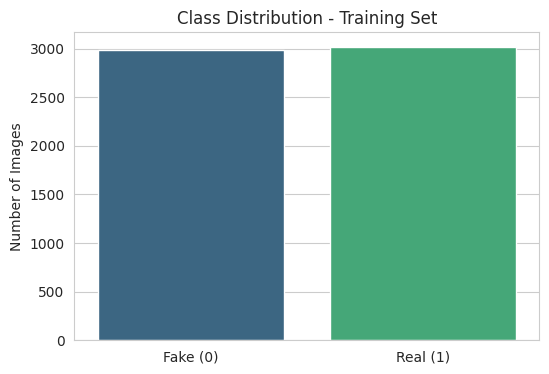

In [11]:
# Graph 1: Class distribution in the training set
plt.figure(figsize=(6, 4))
labels_names = ['Fake (0)', 'Real (1)']
counts = [np.sum(y_train == 0), np.sum(y_train == 1)]
sns.barplot(x=labels_names, y=counts, palette='viridis')
plt.title('Class Distribution - Training Set')
plt.ylabel('Number of Images')
plt.show()

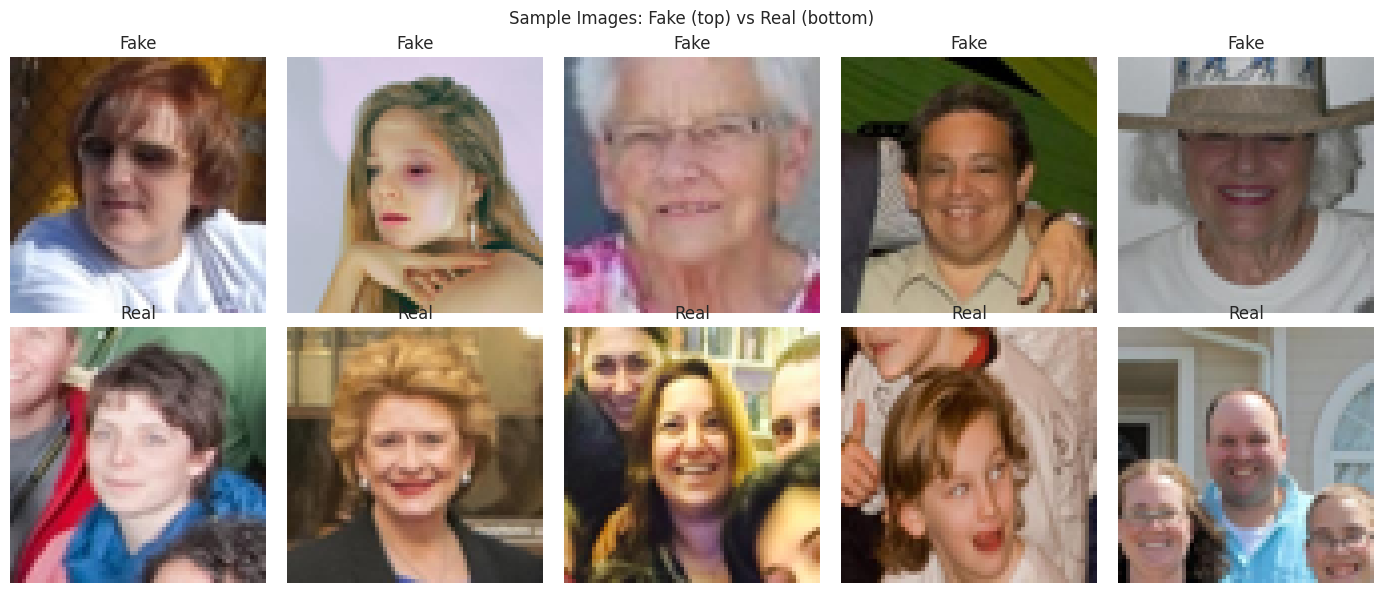

In [12]:
# Graph 2: Sample images grid - Fake vs Real
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fake_idx = np.where(y_train == 0)[0][:5]
real_idx = np.where(y_train == 1)[0][:5]

for col, idx in enumerate(fake_idx):
    axes[0, col].imshow(X_train_raw[idx].astype('uint8'))
    axes[0, col].axis('off')
    axes[0, col].set_title('Fake')

for col, idx in enumerate(real_idx):
    axes[1, col].imshow(X_train_raw[idx].astype('uint8'))
    axes[1, col].axis('off')
    axes[1, col].set_title('Real')

plt.suptitle('Sample Images: Fake (top) vs Real (bottom)')
plt.tight_layout()
plt.show()

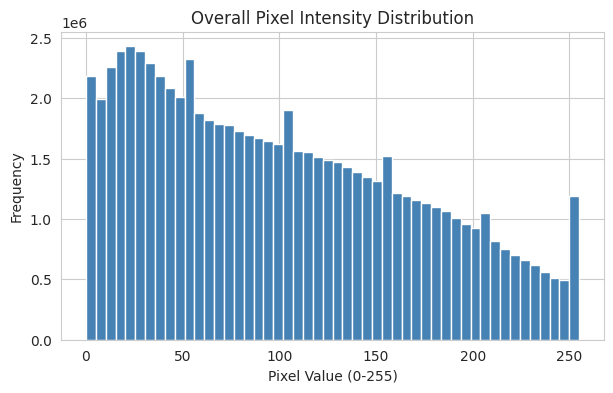

In [13]:
# Graph 3: Overall pixel intensity histogram
plt.figure(figsize=(7, 4))
plt.hist(X_train_raw.flatten(), bins=50, color='steelblue')
plt.title('Overall Pixel Intensity Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.show()

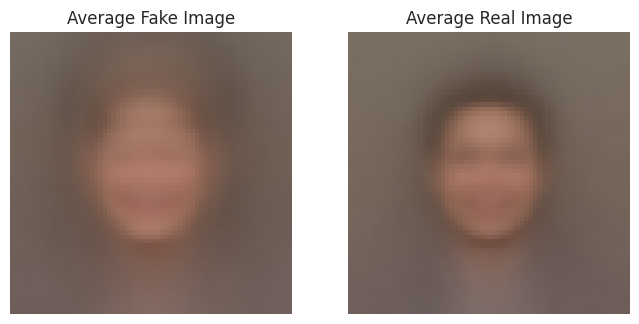

In [14]:
# Graph 4: Average ("mean") image per class
mean_fake_img = X_train_raw[y_train == 0].mean(axis=0).astype('uint8')
mean_real_img = X_train_raw[y_train == 1].mean(axis=0).astype('uint8')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mean_fake_img)
axes[0].set_title('Average Fake Image')
axes[0].axis('off')
axes[1].imshow(mean_real_img)
axes[1].set_title('Average Real Image')
axes[1].axis('off')
plt.show()

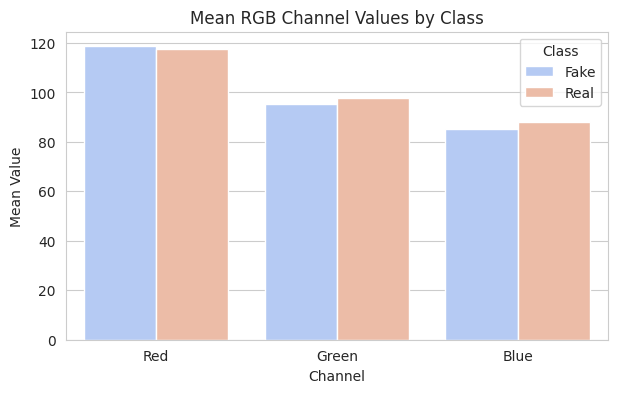

In [15]:
# Graph 5: RGB channel mean value comparison across classes
fake_channel_means = X_train_raw[y_train == 0].mean(axis=(0, 1, 2))
real_channel_means = X_train_raw[y_train == 1].mean(axis=(0, 1, 2))

channel_df = pd.DataFrame({
    'Channel': ['Red', 'Green', 'Blue'] * 2,
    'Mean Value': list(fake_channel_means) + list(real_channel_means),
    'Class': ['Fake'] * 3 + ['Real'] * 3
})

plt.figure(figsize=(7, 4))
sns.barplot(data=channel_df, x='Channel', y='Mean Value', hue='Class', palette='coolwarm')
plt.title('Mean RGB Channel Values by Class')
plt.show()

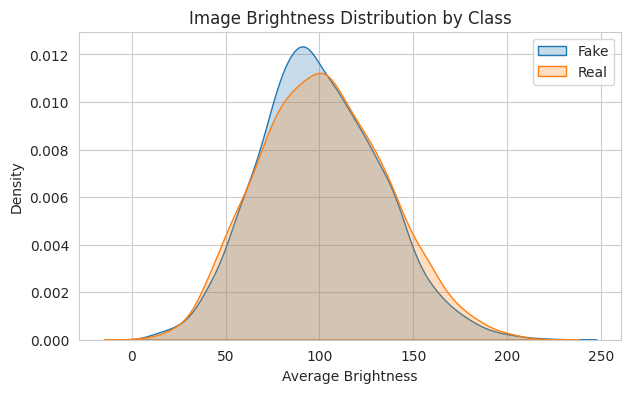

In [16]:
# Graph 6: Image brightness distribution by class
fake_brightness = X_train_raw[y_train == 0].mean(axis=(1, 2, 3))
real_brightness = X_train_raw[y_train == 1].mean(axis=(1, 2, 3))

plt.figure(figsize=(7, 4))
sns.kdeplot(fake_brightness, label='Fake', fill=True)
sns.kdeplot(real_brightness, label='Real', fill=True)
plt.title('Image Brightness Distribution by Class')
plt.xlabel('Average Brightness')
plt.legend()
plt.show()

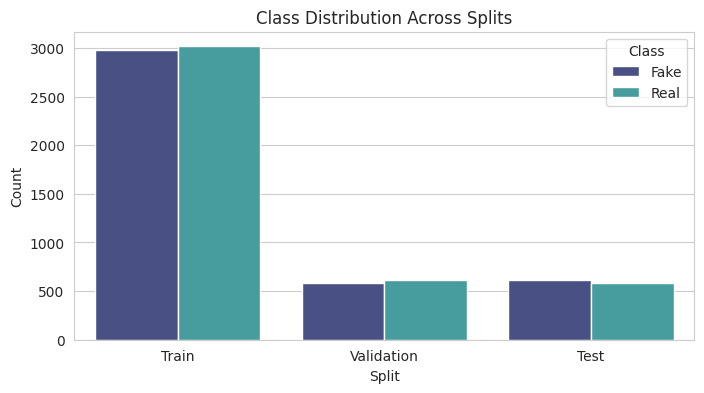

In [17]:
# Graph 7: Class distribution across train/validation/test splits
split_df = pd.DataFrame({
    'Split': ['Train', 'Train', 'Validation', 'Validation', 'Test', 'Test'],
    'Class': ['Fake', 'Real'] * 3,
    'Count': [np.sum(y_train == 0), np.sum(y_train == 1),
              np.sum(y_val == 0), np.sum(y_val == 1),
              np.sum(y_test == 0), np.sum(y_test == 1)]
})

plt.figure(figsize=(8, 4))
sns.barplot(data=split_df, x='Split', y='Count', hue='Class', palette='mako')
plt.title('Class Distribution Across Splits')
plt.show()

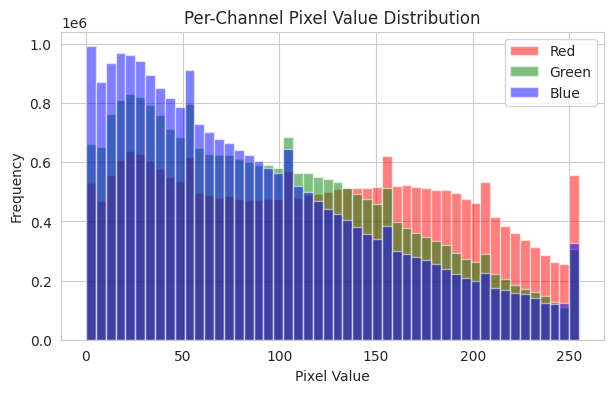

In [18]:
# Graph 8: Per-channel pixel value distribution (R, G, B)
plt.figure(figsize=(7, 4))
colors = ['red', 'green', 'blue']
channel_names = ['Red', 'Green', 'Blue']
for i in range(3):
    plt.hist(X_train_raw[:, :, :, i].flatten(), bins=50, color=colors[i],
             alpha=0.5, label=channel_names[i])
plt.title('Per-Channel Pixel Value Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## 6. Data Pre-processing and Feature Engineering for CNN Models

In [19]:
# Normalize pixel values to the [0, 1] range
X_train = X_train_raw / 255.0
X_val = X_val_raw / 255.0
X_test = X_test_raw / 255.0

print("X_train range:", X_train.min(), "-", X_train.max())
print("X_val range:", X_val.min(), "-", X_val.max())
print("X_test range:", X_test.min(), "-", X_test.max())

X_train range: 0.0 - 1.0
X_val range: 0.0 - 1.0
X_test range: 0.0 - 1.0


In [20]:
# Reshape labels for binary classification (sigmoid output)
y_train = y_train.reshape(-1, 1).astype('float32')
y_val = y_val.reshape(-1, 1).astype('float32')
y_test = y_test.reshape(-1, 1).astype('float32')

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

y_train shape: (6000, 1)
y_val shape: (1200, 1)
y_test shape: (1200, 1)


In [21]:
# Data augmentation generator (feature engineering step) for the training set
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
train_datagen.fit(X_train)

BATCH_SIZE = 32
train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=42)

print("Augmented training generator ready. Steps per epoch:", len(train_generator))

Augmented training generator ready. Steps per epoch: 188


In [22]:
# Input shape used by all three CNN models
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
print("CNN input shape:", INPUT_SHAPE)

CNN input shape: (64, 64, 3)


## 7. CNN Model 1 — Simple Baseline CNN

A shallow 3-convolution-block CNN used as a baseline.

In [23]:
# Model 1: Build - Simple Baseline CNN (Sequential, no pretrained weights)
model_1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=INPUT_SHAPE),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='Model_1_Baseline_CNN')

model_1.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Model_1_Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,081 (4.36 MB)

 Trainable params: 1,142,081 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Model 1: Train
start_time = time.time()

history_1 = model_1.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=10,
    verbose=1
)

model_1_train_time = time.time() - start_time
print("Model 1 training time (seconds):", round(model_1_train_time, 2))

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.5628 - loss: 0.6827 - val_accuracy: 0.6092 - val_loss: 0.6508
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6363 - loss: 0.6370 - val_accuracy: 0.6717 - val_loss: 0.6087
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.6580 - loss: 0.6166 - val_accuracy: 0.6783 - val_loss: 0.6033
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6857 - loss: 0.5839 - val_accuracy: 0.7125 - val_loss: 0.5641
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.7035 - loss: 0.5699 - val_accuracy: 0.6733 - val_loss: 0.5707
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.7035 - loss: 0.5639 - val_accuracy: 0.6900 - val_loss: 0.5629
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.7135 - loss: 0.5523 - val_accuracy: 0.7400 - val_loss: 0.5281
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.7235 - loss: 0.5344 - val_acc

In [25]:
# Model 1: Test - run inference on the held-out test set
model_1_probs = model_1.predict(X_test)
model_1_preds = (model_1_probs > 0.5).astype('int32')

print("Model 1 sample predictions:", model_1_preds[:10].flatten())
print("Model 1 sample true labels:", y_test[:10].flatten())

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Model 1 sample predictions: [1 1 0 0 0 1 1 0 1 1]
Model 1 sample true labels: [1. 0. 1. 0. 0. 0. 1. 0. 0. 1.]


In [26]:
# Model 1: Evaluate
model_1_test_loss, model_1_test_acc = model_1.evaluate(X_test, y_test, verbose=0)

model_1_accuracy = accuracy_score(y_test, model_1_preds)
model_1_precision = precision_score(y_test, model_1_preds)
model_1_recall = recall_score(y_test, model_1_preds)
model_1_f1 = f1_score(y_test, model_1_preds)

print("Model 1 Test Loss:", round(model_1_test_loss, 4))
print("Model 1 Test Accuracy:", round(model_1_accuracy, 4))
print("Model 1 Precision:", round(model_1_precision, 4))
print("Model 1 Recall:", round(model_1_recall, 4))
print("Model 1 F1-score:", round(model_1_f1, 4))
print("\nClassification Report:\n", classification_report(y_test, model_1_preds, target_names=['Fake', 'Real']))

Model 1 Test Loss: 0.5238
Model 1 Test Accuracy: 0.725
Model 1 Precision: 0.6689
Model 1 Recall: 0.8671
Model 1 F1-score: 0.7552

Classification Report:
               precision    recall  f1-score   support

        Fake       0.82      0.59      0.69       613
        Real       0.67      0.87      0.76       587

    accuracy                           0.72      1200
   macro avg       0.75      0.73      0.72      1200
weighted avg       0.75      0.72      0.72      1200



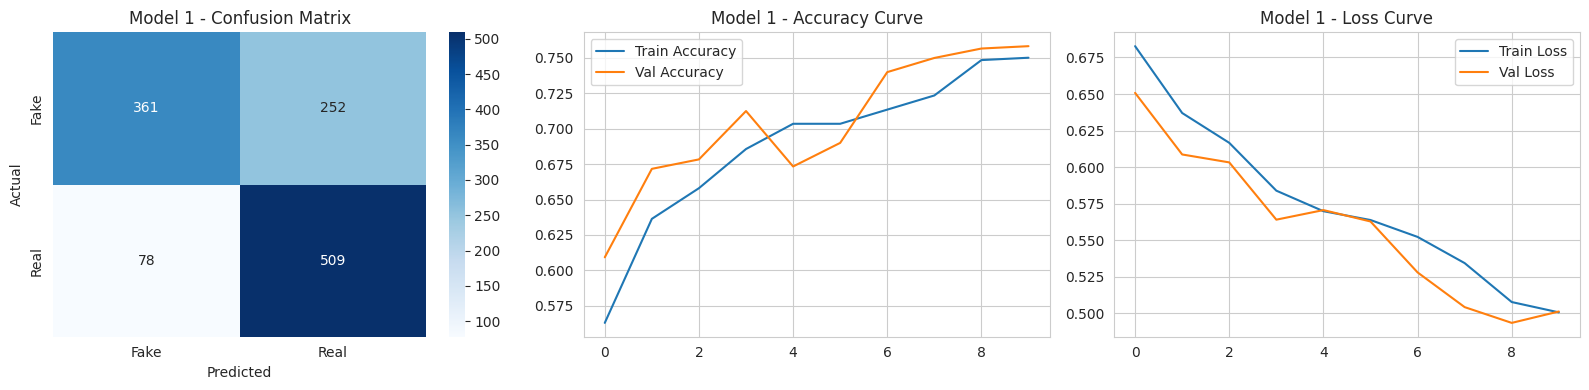

In [27]:
# Model 1: Confusion matrix and training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_1 = confusion_matrix(y_test, model_1_preds)
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
axes[0].set_title('Model 1 - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[1].plot(history_1.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_1.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model 1 - Accuracy Curve')
axes[1].legend()

axes[2].plot(history_1.history['loss'], label='Train Loss')
axes[2].plot(history_1.history['val_loss'], label='Val Loss')
axes[2].set_title('Model 1 - Loss Curve')
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. CNN Model 2 — Deeper CNN with Batch Normalization

A deeper 4-convolution-block CNN with batch normalization for more stable training.

In [28]:
# Model 2: Build - Deeper CNN with Batch Normalization
model_2 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=INPUT_SHAPE),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='Model_2_Deep_BatchNorm_CNN')

model_2.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Model_2_Deep_BatchNorm_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,439,425 (5.49 MB)

 Trainable params: 1,438,465 (5.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [29]:
# Model 2: Train
start_time = time.time()

history_2 = model_2.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=10,
    verbose=1
)

model_2_train_time = time.time() - start_time
print("Model 2 training time (seconds):", round(model_2_train_time, 2))

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.6003 - loss: 0.8371 - val_accuracy: 0.5158 - val_loss: 1.2051
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.6513 - loss: 0.6306 - val_accuracy: 0.6358 - val_loss: 0.6396
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.6800 - loss: 0.5841 - val_accuracy: 0.6567 - val_loss: 0.6360
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.7030 - loss: 0.5661 - val_accuracy: 0.7317 - val_loss: 0.5396
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.7190 - loss: 0.5443 - val_accuracy: 0.6108 - val_loss: 0.7775
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.7238 - loss: 0.5282 - val_accuracy: 0.5900 - val_loss: 0.9130
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.7452 - loss: 0.5149 - val_accuracy: 0.7525 - val_loss: 0.5024
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.7713 - loss: 0.4698 - val_acc

In [30]:
# Model 2: Test - run inference on the held-out test set
model_2_probs = model_2.predict(X_test)
model_2_preds = (model_2_probs > 0.5).astype('int32')

print("Model 2 sample predictions:", model_2_preds[:10].flatten())
print("Model 2 sample true labels:", y_test[:10].flatten())

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Model 2 sample predictions: [1 1 0 0 1 1 1 0 0 1]
Model 2 sample true labels: [1. 0. 1. 0. 0. 0. 1. 0. 0. 1.]


In [31]:
# Model 2: Evaluate
model_2_test_loss, model_2_test_acc = model_2.evaluate(X_test, y_test, verbose=0)

model_2_accuracy = accuracy_score(y_test, model_2_preds)
model_2_precision = precision_score(y_test, model_2_preds)
model_2_recall = recall_score(y_test, model_2_preds)
model_2_f1 = f1_score(y_test, model_2_preds)

print("Model 2 Test Loss:", round(model_2_test_loss, 4))
print("Model 2 Test Accuracy:", round(model_2_accuracy, 4))
print("Model 2 Precision:", round(model_2_precision, 4))
print("Model 2 Recall:", round(model_2_recall, 4))
print("Model 2 F1-score:", round(model_2_f1, 4))
print("\nClassification Report:\n", classification_report(y_test, model_2_preds, target_names=['Fake', 'Real']))

Model 2 Test Loss: 0.5656
Model 2 Test Accuracy: 0.7317
Model 2 Precision: 0.6658
Model 2 Recall: 0.9063
Model 2 F1-score: 0.7677

Classification Report:
               precision    recall  f1-score   support

        Fake       0.86      0.56      0.68       613
        Real       0.67      0.91      0.77       587

    accuracy                           0.73      1200
   macro avg       0.76      0.74      0.73      1200
weighted avg       0.77      0.73      0.72      1200



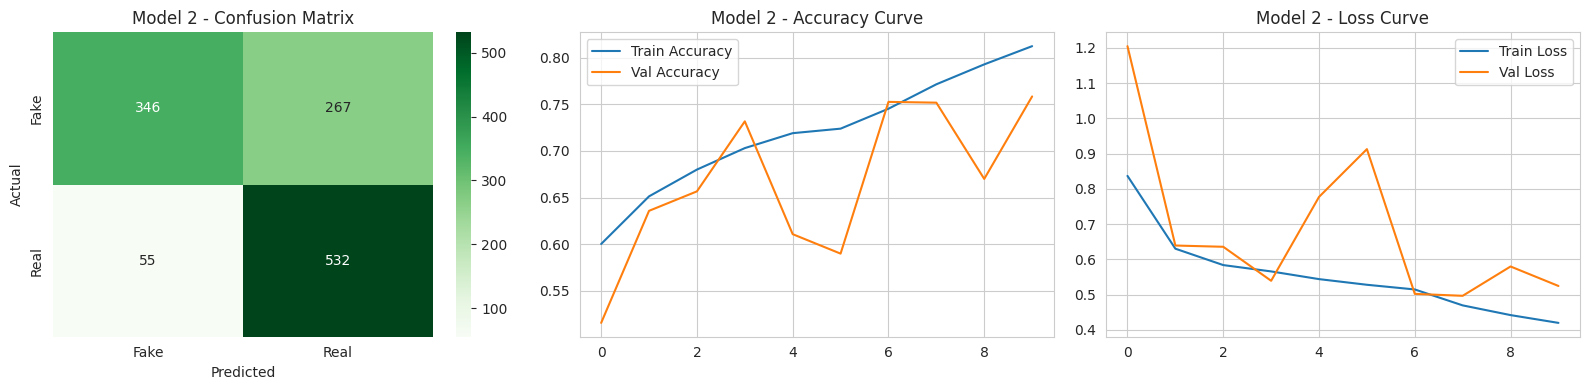

In [32]:
# Model 2: Confusion matrix and training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_2 = confusion_matrix(y_test, model_2_preds)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
axes[0].set_title('Model 2 - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[1].plot(history_2.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_2.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model 2 - Accuracy Curve')
axes[1].legend()

axes[2].plot(history_2.history['loss'], label='Train Loss')
axes[2].plot(history_2.history['val_loss'], label='Val Loss')
axes[2].set_title('Model 2 - Loss Curve')
axes[2].legend()

plt.tight_layout()
plt.show()

## 9. CNN Model 3 — Wide CNN with Global Average Pooling

A wider architecture using stacked convolutions per block and Global Average Pooling
instead of Flatten + large Dense layers, to reduce parameter count and overfitting.

In [33]:
# Model 3: Build - Wide CNN with Global Average Pooling
model_3 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=INPUT_SHAPE),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
], name='Model_3_Wide_GAP_CNN')

model_3.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Model_3_Wide_GAP_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,649 (1.16 MB)

 Trainable params: 303,649 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Model 3: Train
start_time = time.time()

history_3 = model_3.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=10,
    verbose=1
)

model_3_train_time = time.time() - start_time
print("Model 3 training time (seconds):", round(model_3_train_time, 2))

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - accuracy: 0.5088 - loss: 0.6935 - val_accuracy: 0.5258 - val_loss: 0.6924
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.4987 - loss: 0.6933 - val_accuracy: 0.5150 - val_loss: 0.6930
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.5018 - loss: 0.6930 - val_accuracy: 0.5150 - val_loss: 0.6931
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.4888 - loss: 0.6935 - val_accuracy: 0.4850 - val_loss: 0.6932
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.4938 - loss: 0.6933 - val_accuracy: 0.4850 - val_loss: 0.6932
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.5018 - loss: 0.6932 - val_accuracy: 0.5150 - val_loss: 0.6930
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.4847 - loss: 0.6933 - val_accuracy: 0.5150 - val_loss: 0.6929
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.5028 - loss: 0.6932 - val_

In [35]:
# Model 3: Test - run inference on the held-out test set
model_3_probs = model_3.predict(X_test)
model_3_preds = (model_3_probs > 0.5).astype('int32')

print("Model 3 sample predictions:", model_3_preds[:10].flatten())
print("Model 3 sample true labels:", y_test[:10].flatten())

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Model 3 sample predictions: [1 1 1 1 1 1 1 1 1 1]
Model 3 sample true labels: [1. 0. 1. 0. 0. 0. 1. 0. 0. 1.]


In [36]:
# Model 3: Evaluate
model_3_test_loss, model_3_test_acc = model_3.evaluate(X_test, y_test, verbose=0)

model_3_accuracy = accuracy_score(y_test, model_3_preds)
model_3_precision = precision_score(y_test, model_3_preds)
model_3_recall = recall_score(y_test, model_3_preds)
model_3_f1 = f1_score(y_test, model_3_preds)

print("Model 3 Test Loss:", round(model_3_test_loss, 4))
print("Model 3 Test Accuracy:", round(model_3_accuracy, 4))
print("Model 3 Precision:", round(model_3_precision, 4))
print("Model 3 Recall:", round(model_3_recall, 4))
print("Model 3 F1-score:", round(model_3_f1, 4))
print("\nClassification Report:\n", classification_report(y_test, model_3_preds, target_names=['Fake', 'Real']))

Model 3 Test Loss: 0.6934
Model 3 Test Accuracy: 0.4892
Model 3 Precision: 0.4892
Model 3 Recall: 1.0
Model 3 F1-score: 0.657

Classification Report:
               precision    recall  f1-score   support

        Fake       0.00      0.00      0.00       613
        Real       0.49      1.00      0.66       587

    accuracy                           0.49      1200
   macro avg       0.24      0.50      0.33      1200
weighted avg       0.24      0.49      0.32      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


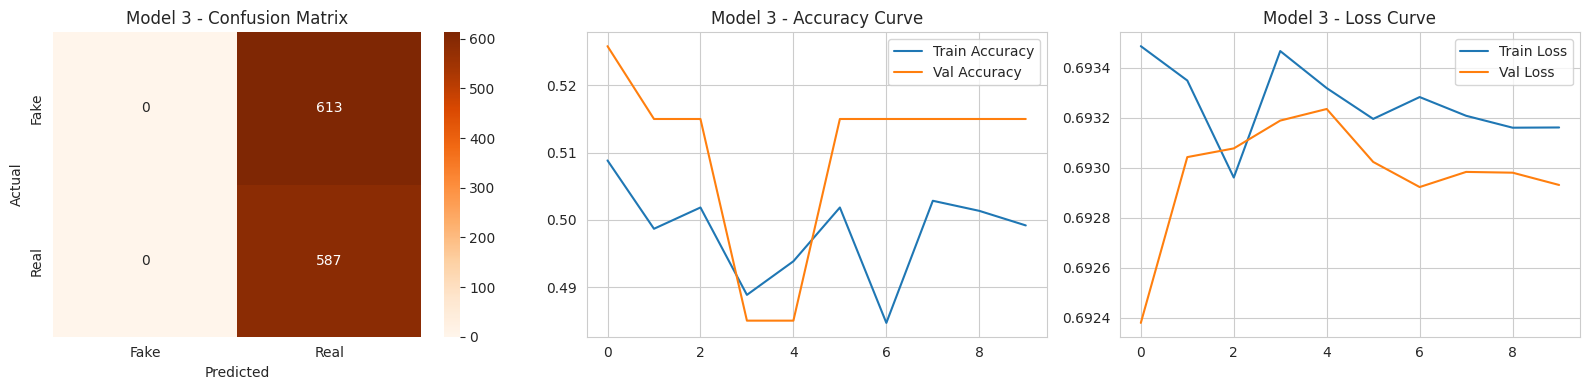

In [37]:
# Model 3: Confusion matrix and training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_3 = confusion_matrix(y_test, model_3_preds)
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
axes[0].set_title('Model 3 - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[1].plot(history_3.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_3.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model 3 - Accuracy Curve')
axes[1].legend()

axes[2].plot(history_3.history['loss'], label='Train Loss')
axes[2].plot(history_3.history['val_loss'], label='Val Loss')
axes[2].set_title('Model 3 - Loss Curve')
axes[2].legend()

plt.tight_layout()
plt.show()

## 10. Model Comparison

In [38]:
# Comparison table across all three models
comparison_df = pd.DataFrame({
    'Model': ['Model 1: Baseline CNN', 'Model 2: Deep BatchNorm CNN', 'Model 3: Wide GAP CNN'],
    'Test Accuracy': [model_1_accuracy, model_2_accuracy, model_3_accuracy],
    'Precision': [model_1_precision, model_2_precision, model_3_precision],
    'Recall': [model_1_recall, model_2_recall, model_3_recall],
    'F1-score': [model_1_f1, model_2_f1, model_3_f1],
    'Test Loss': [model_1_test_loss, model_2_test_loss, model_3_test_loss],
    'Params': [model_1.count_params(), model_2.count_params(), model_3.count_params()],
    'Train Time (s)': [round(model_1_train_time, 1), round(model_2_train_time, 1), round(model_3_train_time, 1)]
})

comparison_df

,Model,Test Accuracy,Precision,Recall,F1-score,Test Loss,Params,Train Time (s)
0,Model 1: Baseline CNN,0.725000,0.668857,0.867121,0.755193,0.523845,1142081,99.3
1,Model 2: Deep BatchNorm CNN,0.731667,0.665832,0.906303,0.767677,0.565627,1439425,100.1
2,Model 3: Wide GAP CNN,0.489167,0.489167,1.000000,0.656967,0.693364,303649,108.8


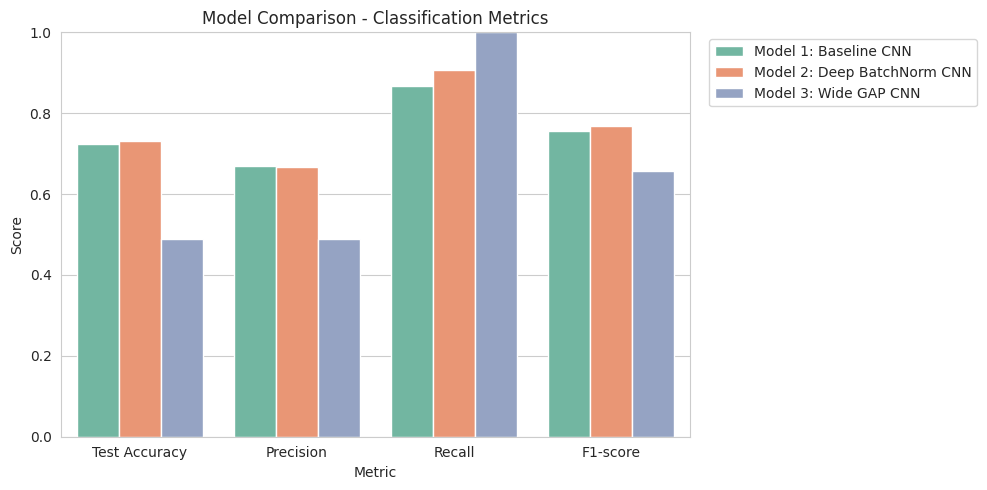

In [39]:
# Graph: Accuracy / Precision / Recall / F1 comparison across models
metrics_melt = comparison_df.melt(
    id_vars='Model',
    value_vars=['Test Accuracy', 'Precision', 'Recall', 'F1-score'],
    var_name='Metric', value_name='Score'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_melt, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title('Model Comparison - Classification Metrics')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

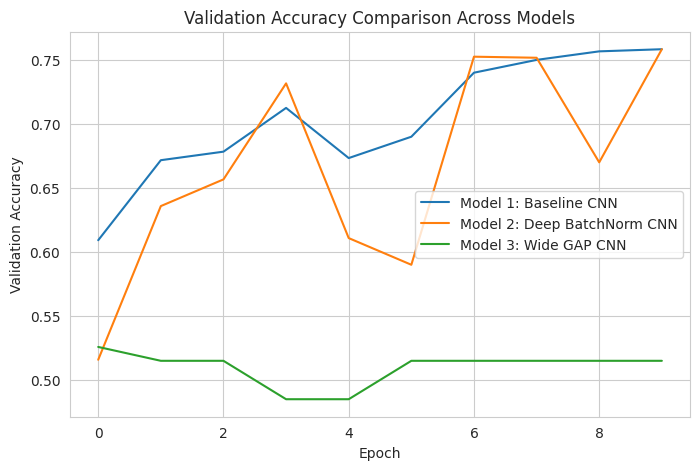

In [40]:
# Graph: Validation accuracy curves overlaid for all three models
plt.figure(figsize=(8, 5))
plt.plot(history_1.history['val_accuracy'], label='Model 1: Baseline CNN')
plt.plot(history_2.history['val_accuracy'], label='Model 2: Deep BatchNorm CNN')
plt.plot(history_3.history['val_accuracy'], label='Model 3: Wide GAP CNN')
plt.title('Validation Accuracy Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

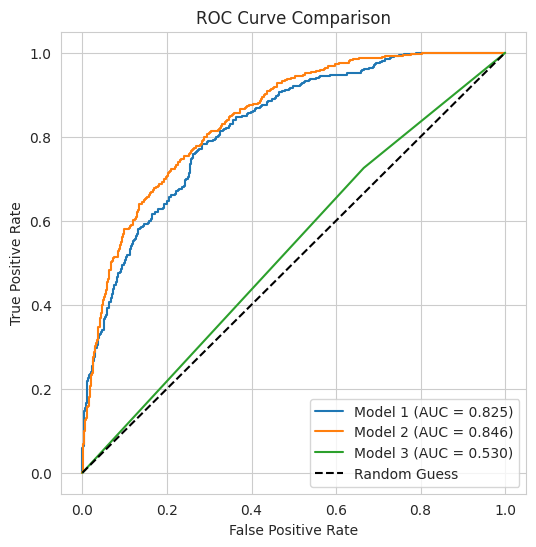

In [41]:
# Graph: ROC curves for all three models
fpr_1, tpr_1, _ = roc_curve(y_test, model_1_probs)
fpr_2, tpr_2, _ = roc_curve(y_test, model_2_probs)
fpr_3, tpr_3, _ = roc_curve(y_test, model_3_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr_1, tpr_1, label='Model 1 (AUC = %.3f)' % auc(fpr_1, tpr_1))
plt.plot(fpr_2, tpr_2, label='Model 2 (AUC = %.3f)' % auc(fpr_2, tpr_2))
plt.plot(fpr_3, tpr_3, label='Model 3 (AUC = %.3f)' % auc(fpr_3, tpr_3))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [42]:
# Identify the best-performing model based on test accuracy
best_row = comparison_df.loc[comparison_df['Test Accuracy'].idxmax()]
print("Best performing model:", best_row['Model'])
print("Test Accuracy:", round(best_row['Test Accuracy'], 4))
print("F1-score:", round(best_row['F1-score'], 4))

Best performing model: Model 2: Deep BatchNorm CNN
Test Accuracy: 0.7317
F1-score: 0.7677


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


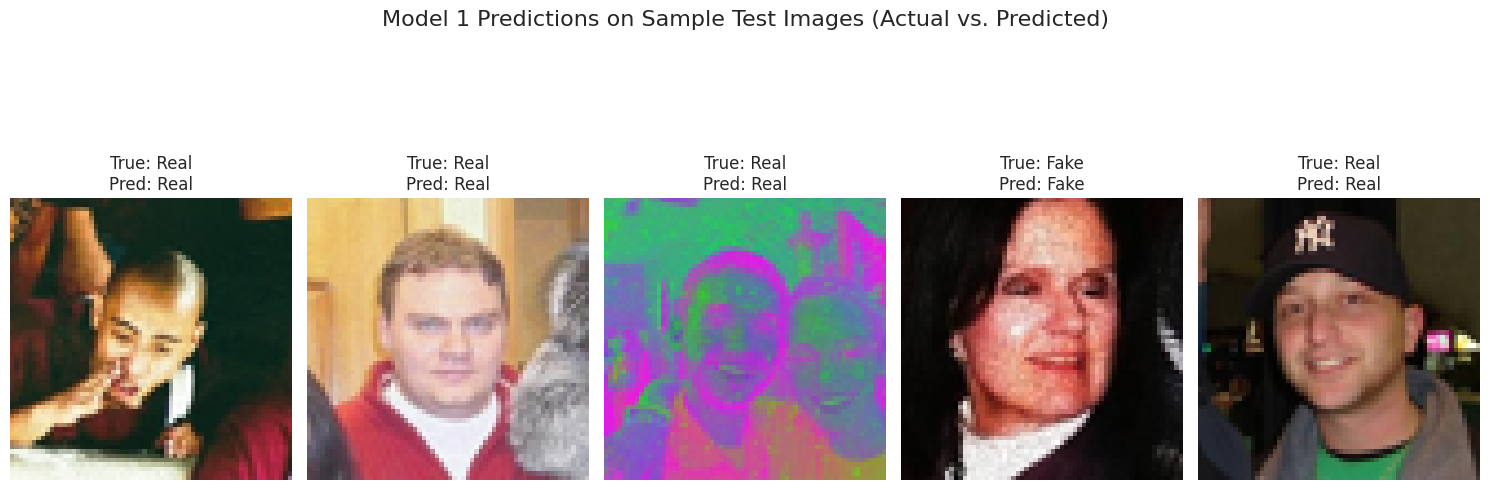

In [44]:
num_samples = 5

# Get random indices from the test set
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

# Retrieve sample images and their true labels
sample_images = X_test_raw[random_indices] # Use raw images for display
sample_true_labels = y_test[random_indices]

# Make predictions using the best model (Model 1)
sample_predictions_probs = model_1.predict(X_test[random_indices])
sample_predictions = (sample_predictions_probs > 0.5).astype('int32')

# Plotting the sample images with predictions
plt.figure(figsize=(15, 6))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(sample_images[i].astype('uint8'))
    true_label_text = 'Real' if sample_true_labels[i] == 1 else 'Fake'
    predicted_label_text = 'Real' if sample_predictions[i] == 1 else 'Fake'

    plt.title(f"True: {true_label_text}\nPred: {predicted_label_text}")
    plt.axis('off')

plt.suptitle('Model 1 Predictions on Sample Test Images (Actual vs. Predicted)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [45]:
# Save the best-performing model (based on test accuracy) for inference
best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
best_model = {'Model 1: Baseline CNN': model_1,
              'Model 2: Deep BatchNorm CNN': model_2,
              'Model 3: Wide GAP CNN': model_3}[best_model_name]

best_model.save('deepfake_model.keras')
print("Saved:", best_model_name, "-> deepfake_model.keras")

Saved: Model 2: Deep BatchNorm CNN -> deepfake_model.keras


### Streamlit app file

In [46]:
%%writefile app.py
import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf

IMG_SIZE = 64

@st.cache_resource
def load_model():
    return tf.keras.models.load_model('deepfake_model.keras')

model = load_model()

st.set_page_config(page_title="Deepfake Detector", page_icon="🕵️")
st.title("🕵️ Deepfake vs Real Image Classifier")
st.write("Upload an image to check whether it's Real or Fake (deepfake).")

uploaded_file = st.file_uploader("Choose an image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    img = Image.open(uploaded_file).convert('RGB')
    st.image(img, caption="Uploaded Image", use_container_width=True)

    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img_resized, dtype='float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prob = model.predict(img_array)[0][0]
    label = "Real" if prob > 0.5 else "Fake"
    confidence = prob if prob > 0.5 else 1 - prob

    st.subheader(f"Prediction: **{label}**")
    st.write(f"Confidence: {confidence*100:.2f}%")
    st.progress(float(confidence))

Writing app.py


In [47]:
!pip install -q streamlit pyngrok
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.7 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
added 22 packages in 2s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.2
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.2
npm notice To update run: npm install -g npm@12.0.2
npm notice
⠧

In [49]:
from pyngrok import ngrok
import subprocess, time

NGROK_TOKEN = "3Cg3o4xJLJJqj0JVoVnWSruazo0_4PkG5HLgHT5HVhtz7UFmw"
ngrok.set_auth_token(NGROK_TOKEN)

subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501', '--server.headless', 'true'])
time.sleep(5)

public_url = ngrok.connect(8501)
print("Streamlit app link:", public_url)

Streamlit app link: NgrokTunnel: "https://active-ivy-retreat.ngrok-free.dev" -> "http://localhost:8501"
